In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 14})

# Ajout du dossier source au chemin pour importer config si nécessaire
sys.path.append(os.path.abspath("../src"))

In [2]:
# Chargement du dataset
data_path = "../data/raw/customer_churn_business_dataset.csv"
df = pd.read_csv(data_path)

print(f"Dimensions du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.\n")
print(df.info())
df.head()

Dimensions du dataset : 10000 lignes et 32 colonnes.

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [3]:
print("--- Valeurs manquantes par colonne ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Aucune valeur manquante détectée.")

print("\n--- Vérification des doublons ---")
duplicates = df.duplicated(subset=['customer_id']).sum()
print(f"Nombre de doublons sur l'identifiant client : {duplicates}")

--- Valeurs manquantes par colonne ---
complaint_type    2045
dtype: int64

--- Vérification des doublons ---
Nombre de doublons sur l'identifiant client : 0


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_48892\1191155778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='churn', data=df, palette='Set2')


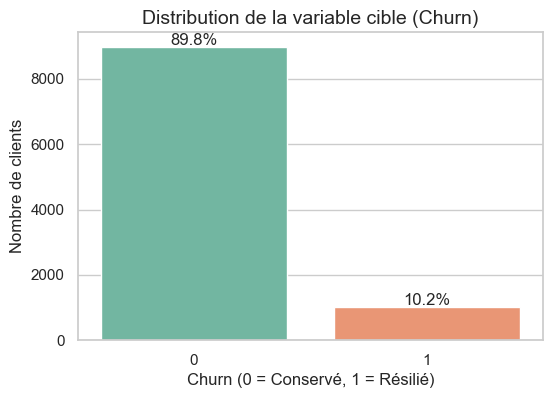

churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='churn', data=df, palette='Set2')
plt.title("Distribution de la variable cible (Churn)")
plt.xlabel("Churn (0 = Conservé, 1 = Résilié)")
plt.ylabel("Nombre de clients")

# Affichage des pourcentages
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 50), ha='center')

plt.show()

print(df['churn'].value_counts(normalize=True))

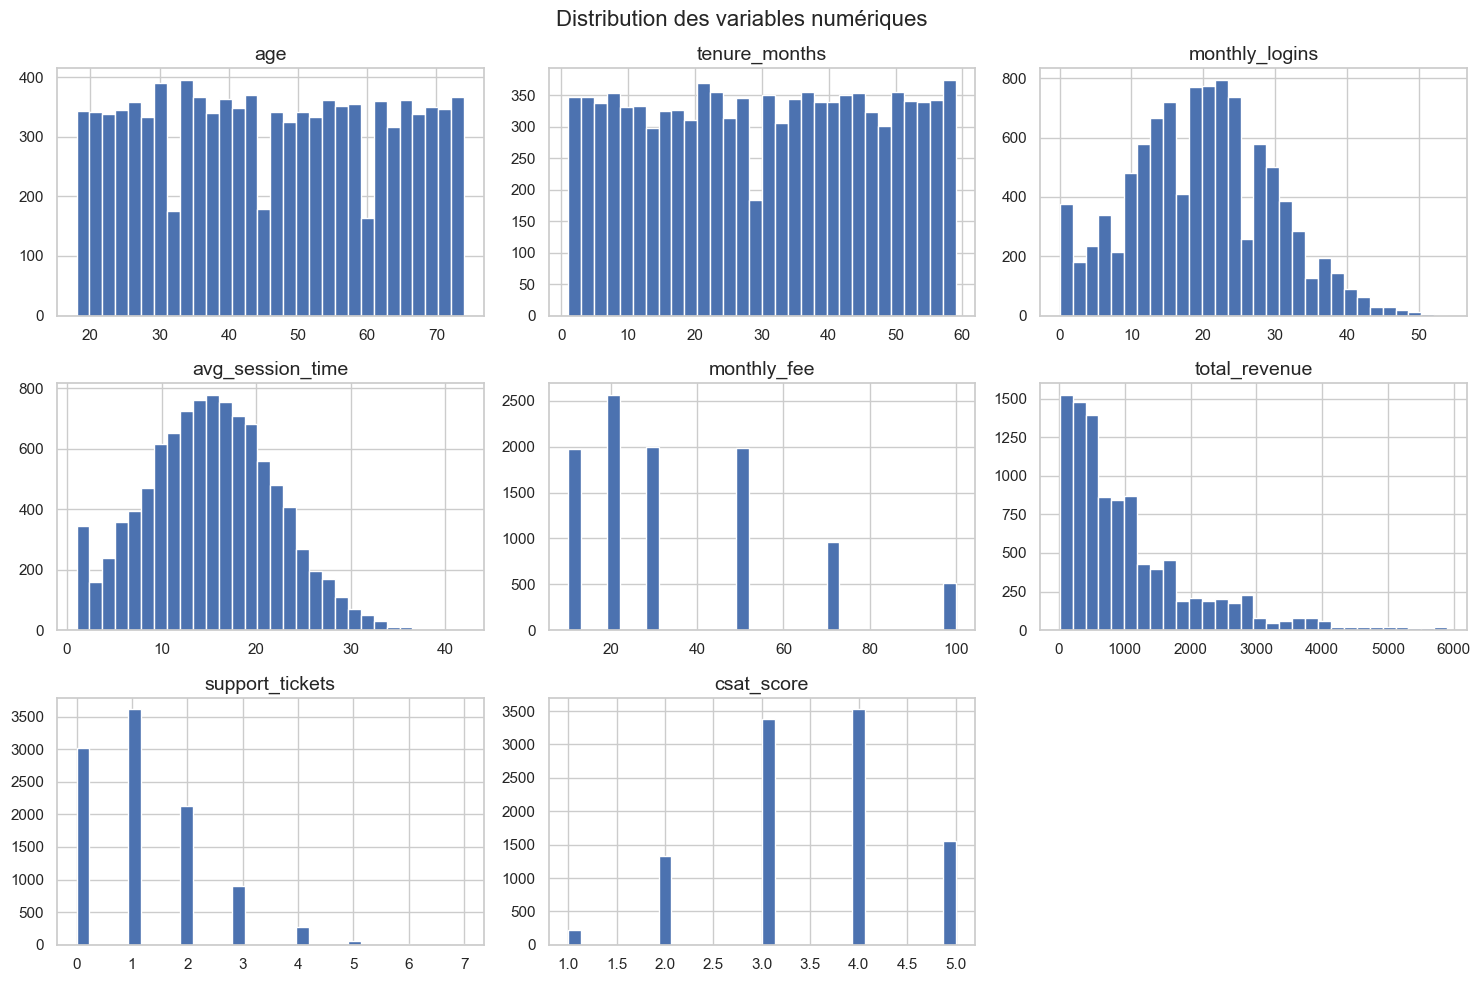

In [5]:
# Sélection des variables numériques clés pour l'affichage
num_cols = ['age', 'tenure_months', 'monthly_logins', 'avg_session_time', 
            'monthly_fee', 'total_revenue', 'support_tickets', 'csat_score']

df[num_cols].hist(bins=30, figsize=(15, 10), layout=(3, 3))
plt.suptitle("Distribution des variables numériques", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_48892\722819259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], x='churn', y='total_revenue', data=df, palette='Pastel1')
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_48892\722819259.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], x='churn', y='avg_session_time', data=df, palette='Pastel1')
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_48892\722819259.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], x='churn', y='suppor

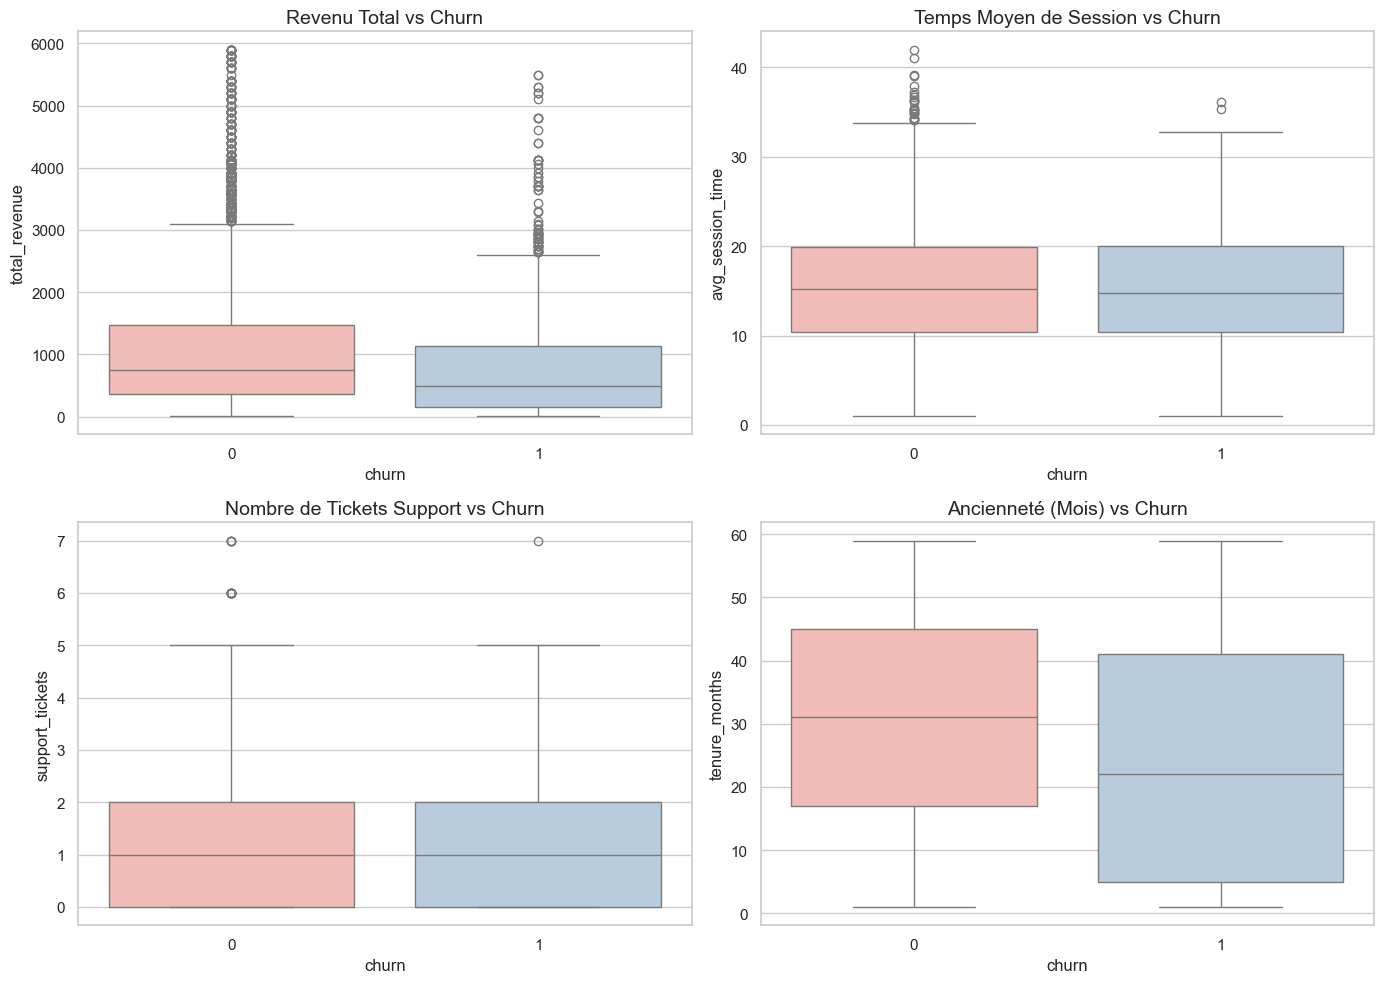

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(ax=axes[0, 0], x='churn', y='total_revenue', data=df, palette='Pastel1')
axes[0, 0].set_title('Revenu Total vs Churn')

sns.boxplot(ax=axes[0, 1], x='churn', y='avg_session_time', data=df, palette='Pastel1')
axes[0, 1].set_title('Temps Moyen de Session vs Churn')

sns.boxplot(ax=axes[1, 0], x='churn', y='support_tickets', data=df, palette='Pastel1')
axes[1, 0].set_title('Nombre de Tickets Support vs Churn')

sns.boxplot(ax=axes[1, 1], x='churn', y='tenure_months', data=df, palette='Pastel1')
axes[1, 1].set_title("Ancienneté (Mois) vs Churn")

plt.tight_layout()
plt.show()

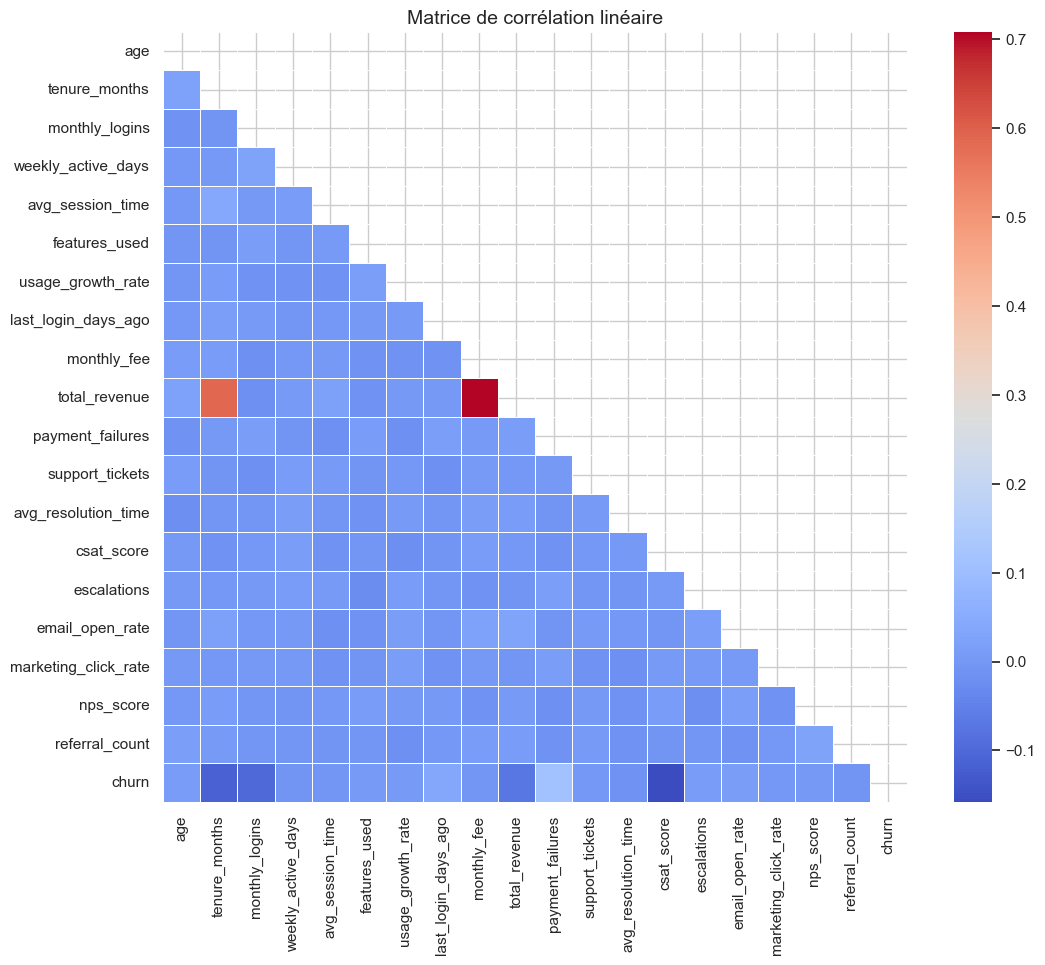

Top des corrélations avec la variable Churn :
churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64


In [7]:
plt.figure(figsize=(12, 10))
# Calcul de la corrélation sur les variables numériques uniquement
corr_matrix = df.select_dtypes(include=[np.number]).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation linéaire")
plt.show()

# Focus sur les corrélations les plus fortes avec le Churn
print("Top des corrélations avec la variable Churn :")
print(corr_matrix['churn'].sort_values(ascending=False))

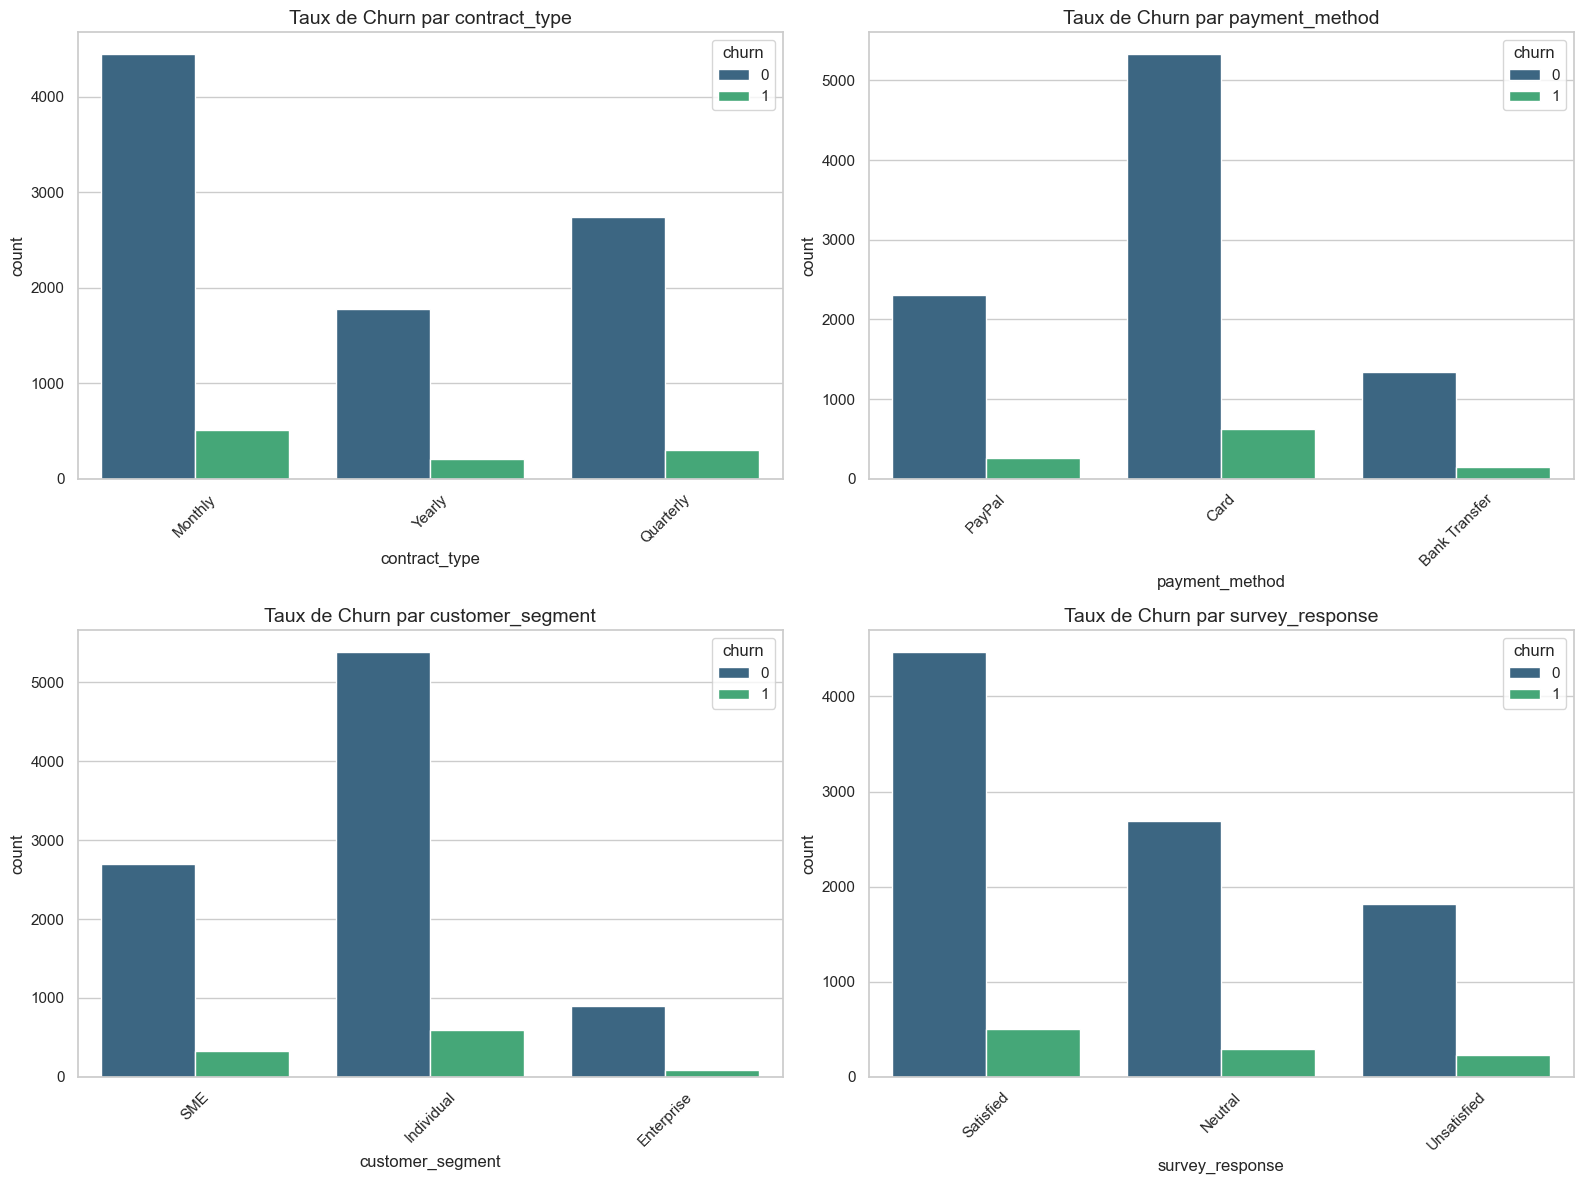

In [8]:
cat_cols = ['contract_type', 'payment_method', 'customer_segment', 'survey_response']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(ax=axes[i], x=col, hue='churn', data=df, palette='viridis')
    axes[i].set_title(f'Taux de Churn par {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()